In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

In [2]:
meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/big_meta_mapping.tab"
umap_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/big_umap.csv"

plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
# colors
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

In [3]:
meta = read.csv(meta_in, sep='\t')
umap = read.csv(umap_in)
meta = merge(meta, umap, by='cell')

In [4]:
meta$origin = sapply(strsplit(meta$sample,'\\_'), "[", 1)

In [54]:
p1 = ggplot(meta, aes(umap_1, umap_2, color=stage)) +
    geom_point(alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = stage_colours, labels = stage_labels, name = "stage") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank(),
          legend.position = 'none') +
          labs(color = "log distances", text = element_text(size = 40)) + 
          ggtitle('Collection timepoint')

p1_legend = ggplot(meta, aes(umap_1, umap_2, color=stage)) +
     geom_point(alpha=1, size = 5) +
     scale_colour_manual(values = stage_colours, labels = stage_labels, name = "Stage") + 
    theme_classic() + 
    theme(text = element_text(size=20))

p2 = ggplot(meta, aes(umap_1, umap_2, color=origin)) +
    geom_point(alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('atlas' = '#dbdbdb', 'mixl' = '#000000'), labels = c('atlas' = 'Atlas', 'mixl' = 'Chimaera'), name = "Origin") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank(), legend.position = 'none') +
          labs(color = "log distances", text = element_text(size = 40)) + 
          ggtitle('Origin')

p2_legend = ggplot(meta, aes(umap_1, umap_2, color=origin)) +
     geom_point(alpha=1, size = 5) +
     scale_colour_manual(values = c('atlas' = '#dbdbdb', 'mixl' = '#000000'), labels = c('atlas' = 'Atlas', 'mixl' = 'Chimaera'), name = "Origin") +
    theme_classic() + 
    theme(text = element_text(size=20))

In [55]:
p = plot_grid(p1, get_legend(p1_legend), p2, get_legend(p2_legend), rel_widths = c(0.4, 0.1, 0.4, 0.1), ncol = 4)

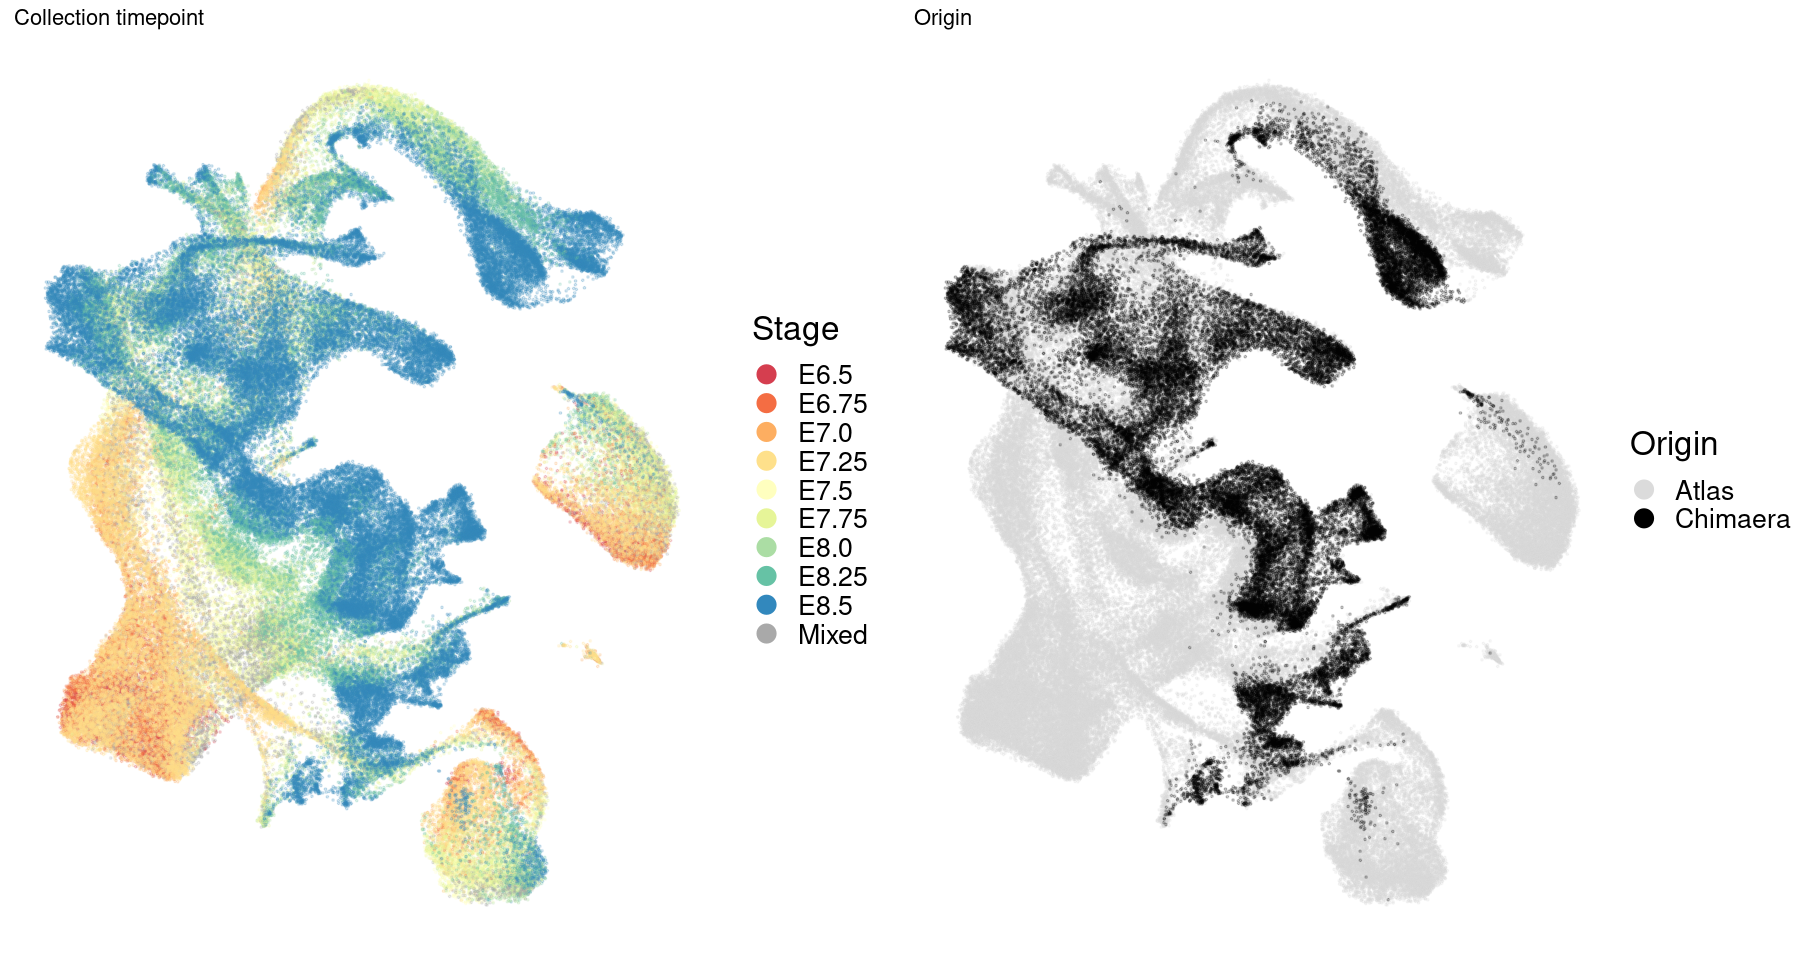

In [56]:
options(repr.plot.width = 15, repr.plot.height = 8)
p

In [58]:
png(paste0(plot_folder, "umap_stage_origin.png"), width = 1500, height = 500)
    p
dev.off()

png 
  2

In [7]:
unique(meta$tdTom)

[1] NA    "neg" "pos"

In [5]:
meta$tdTom[is.na(meta$tdTom)] = 'Atlas'

In [47]:
p1 = ggplot(meta, aes(umap_1, umap_2, color=tdTom)) +
    geom_point(alpha=0.4, size = 1) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = '#FF0000', 'neg' = '#000000', 'Atlas' = '#dbdbdb'), labels = c('pos' = 'Positive', 'neg' = 'Negative', 'Atlas' = 'Atlas'), name = "Tomato-Td") +
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank(),
          legend.position = 'none') +
          labs(color = "log distances", text = element_text(size = 40))

p1_legend = ggplot(meta, aes(umap_1, umap_2, color=tdTom)) +
     geom_point(alpha=1, size = 10) +
     scale_colour_manual(values = c('pos' = '#FF0000', 'neg' = '#000000', 'Atlas' = '#dbdbdb'), labels = c('pos' = 'Positive', 'neg' = 'Negative', 'Atlas' = 'Atlas'), name = "Tomato-Td") +
     theme_classic() + 
    theme(text = element_text(size=45))

png 
  2

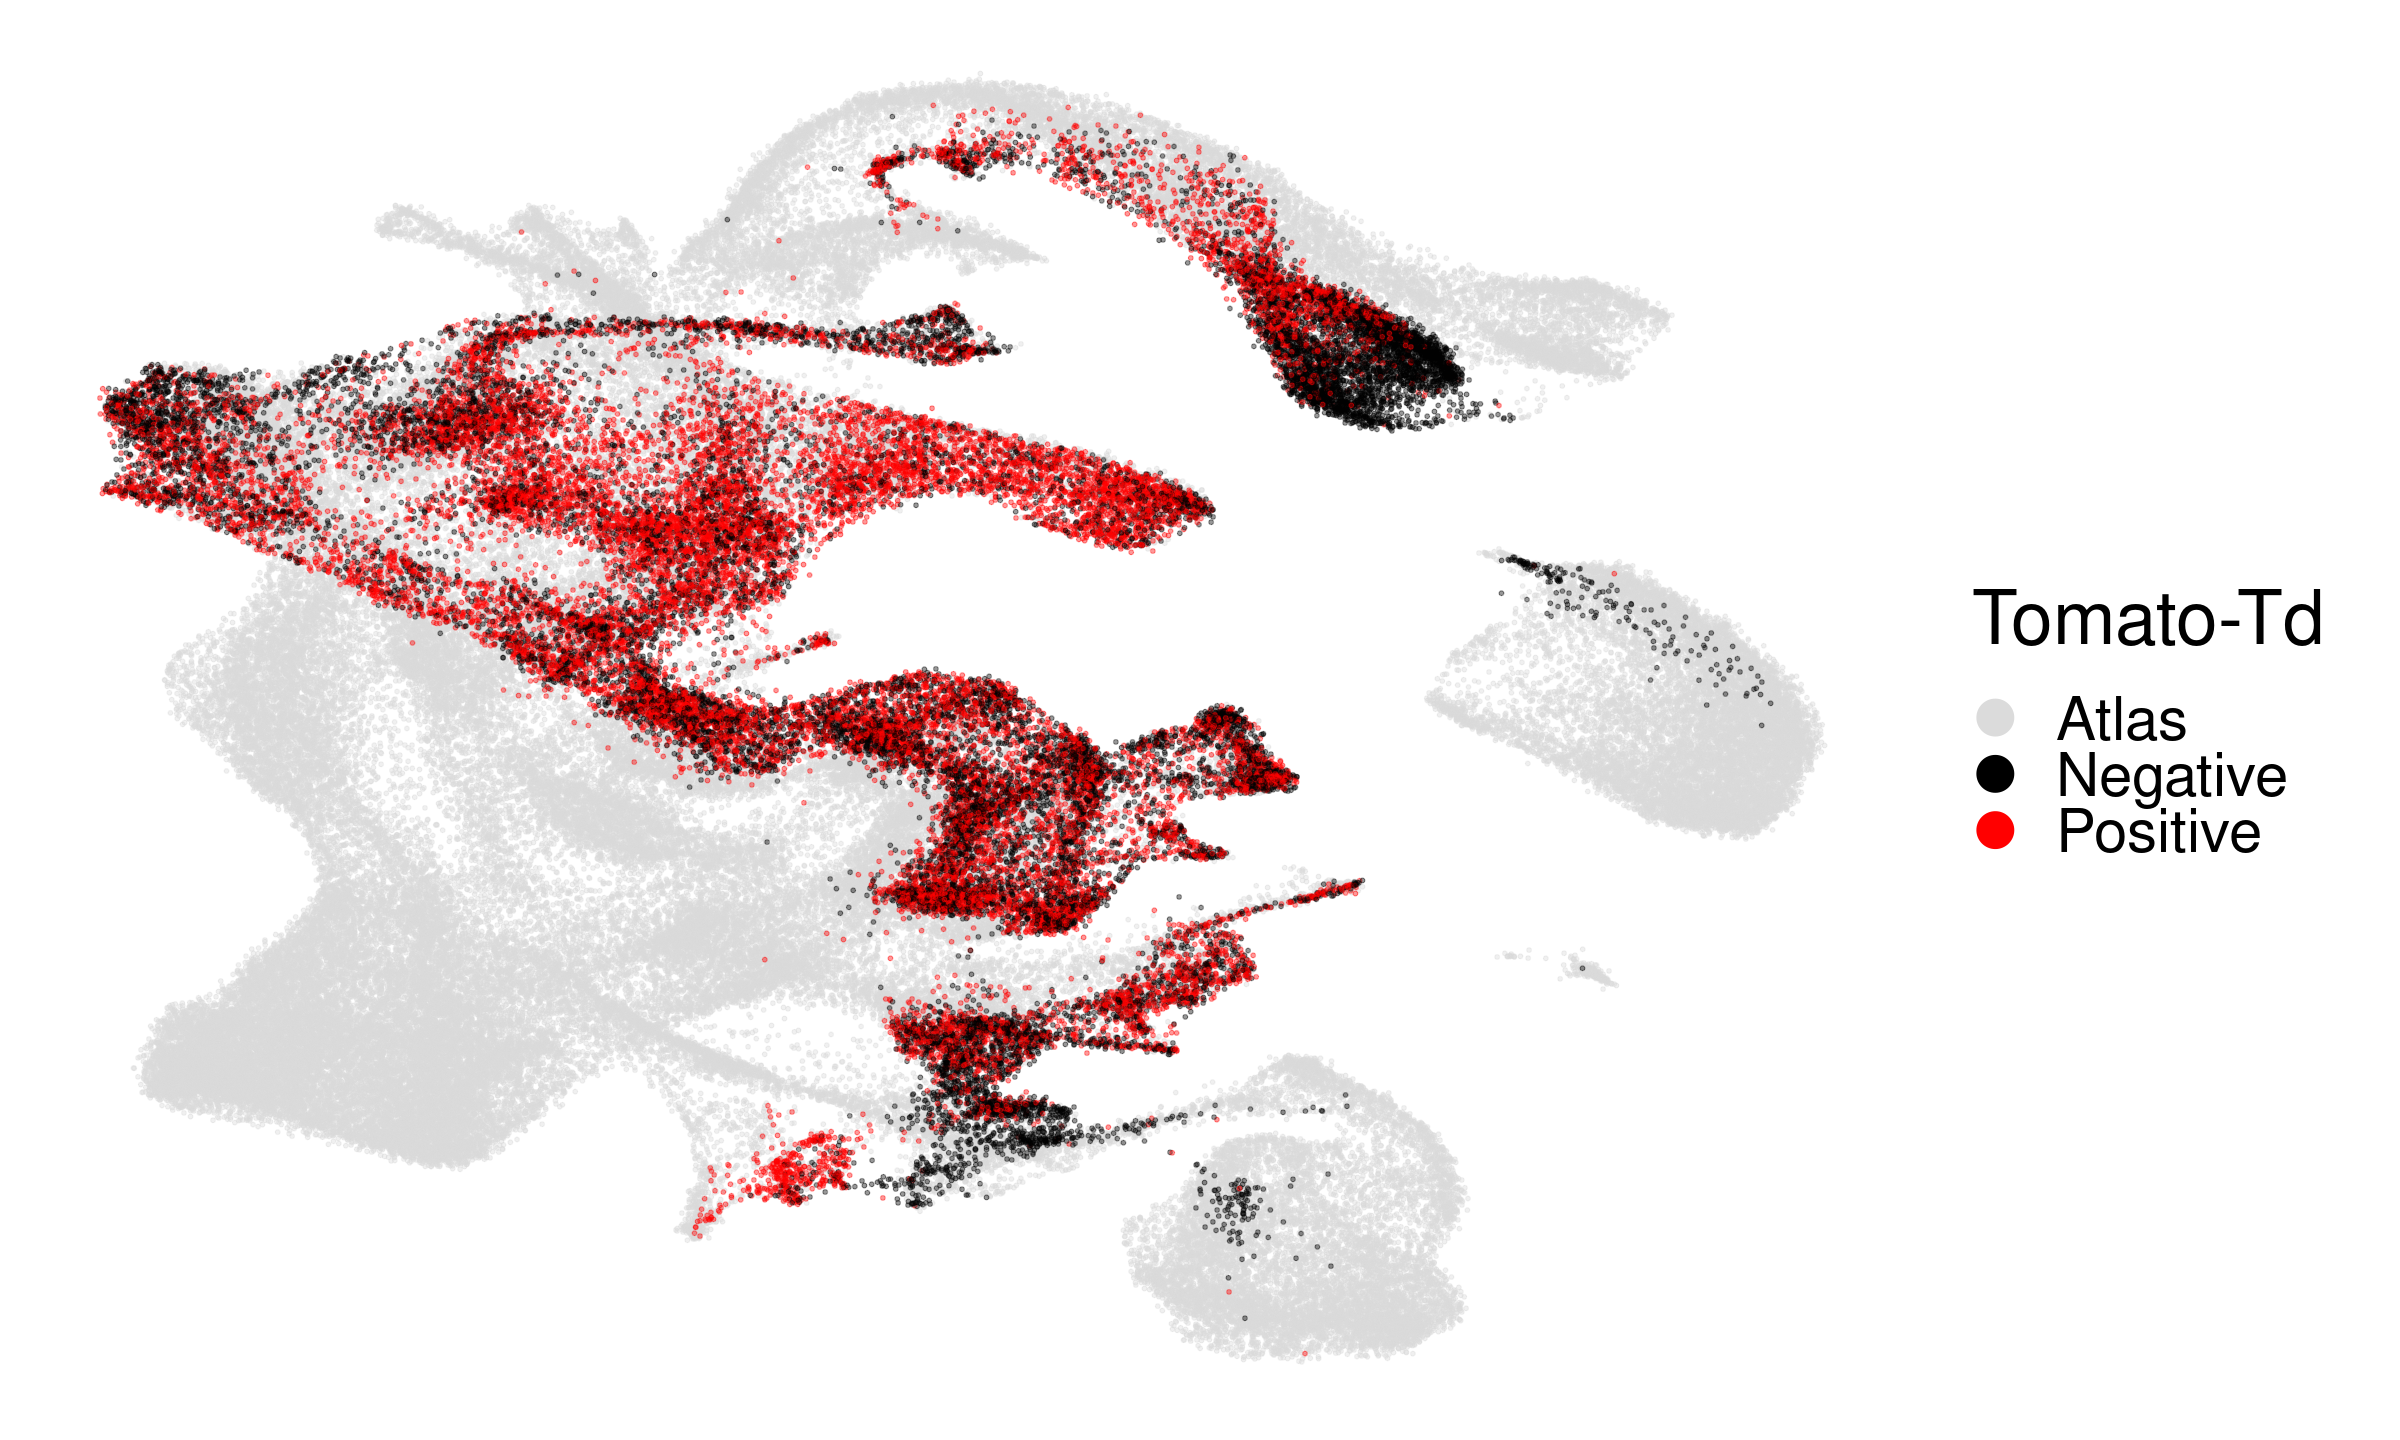

In [49]:
options(repr.plot.width = 20, repr.plot.height = 12)
p = plot_grid(p1, get_legend(p1_legend), rel_widths = c(0.4, 0.1))
p

png(paste0(plot_folder, "umap_tomatotd.png"), width = 1500, height = 1000)
    p
dev.off()

In [ ]:
p1 = ggplot(meta, aes(umap_1, umap_2, color=cel)) +
    geom_point(alpha=0.4, size = 1) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = '#FF0000', 'neg' = '#000000', 'Atlas' = '#dbdbdb'), labels = c('pos' = 'Positive', 'neg' = 'Negative', 'Atlas' = 'Atlas'), name = "Tomato-Td") +
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank(),
          legend.position = 'none') +
          labs(color = "log distances", text = element_text(size = 40))

p1_legend = ggplot(meta, aes(umap_1, umap_2, color=tdTom)) +
     geom_point(alpha=1, size = 10) +
     scale_colour_manual(values = c('pos' = '#FF0000', 'neg' = '#000000', 'Atlas' = '#dbdbdb'), labels = c('pos' = 'Positive', 'neg' = 'Negative', 'Atlas' = 'Atlas'), name = "Tomato-Td") +
     theme_classic() + 
    theme(text = element_text(size=45))

options(repr.plot.width = 20, repr.plot.height = 12)
p = plot_grid(p1, get_legend(p1_legend), rel_widths = c(0.4, 0.1))
p

### Plot violin per celltype

In [11]:
chim = meta %>% filter(origin == 'mixl')

In [14]:
head(chim)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,tdTom,umap_1,umap_2,origin
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,chim_cell_1,mixl_1,E8.5,AAACCCAAGCATAGGC,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139332,E8.25,Paraxial mesoderm,atlas_cell_74754,neg,-7.566971,12.385644,mixl
2,chim_cell_10,mixl_1,E8.5,AAACCCATCATTGGTG,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139341,E8.25,Erythroid2,atlas_cell_63543,neg,8.305508,13.469459,mixl
3,chim_cell_100,mixl_1,E8.5,AACAACCCAGGCACAA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139431,E8.25,Spinal cord,atlas_cell_66571,neg,1.088866,5.489112,mixl
4,chim_cell_1000,mixl_1,E8.5,AGATGAATCTAGTCAG,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,140331,E8.5,Cardiomyocytes,atlas_cell_76440,neg,1.655879,13.760590,mixl
5,chim_cell_10000,mixl_2,E8.5,ATTACCTAGGTGAGAA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,149331,E8.25,Somitic mesoderm,atlas_cell_74112,pos,-2.432720,7.236650,mixl
6,chim_cell_10001,mixl_2,E8.5,ATTACCTCACGCCACA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,149332,E8.0,Intermediate mesoderm,atlas_cell_18800,pos,-4.222797,8.913775,mixl


In [39]:
meta$count = 1


In [40]:
head(pdf)

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,Allantois,neg,4.075772e-02
2,Anterior Primitive Streak,neg,5.522726e-05
3,Blood progenitors 1,neg,3.092727e-03
4,Blood progenitors 2,neg,1.159772e-02
5,Cardiomyocytes,neg,3.816204e-02
6,Caudal epiblast,neg,2.209090e-04


In [82]:
head(chim)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,tdTom,umap_1,umap_2,origin,count
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,chim_cell_1,mixl_1,E8.5,AAACCCAAGCATAGGC,1,FALSE,FALSE,NA,NA,NA,⋯,NA,139332,E8.25,Paraxial mesoderm,atlas_cell_74754,neg,-7.566971,12.385644,mixl,1
2,chim_cell_10,mixl_1,E8.5,AAACCCATCATTGGTG,1,FALSE,FALSE,NA,NA,NA,⋯,NA,139341,E8.25,Erythroid2,atlas_cell_63543,neg,8.305508,13.469459,mixl,1
3,chim_cell_100,mixl_1,E8.5,AACAACCCAGGCACAA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,139431,E8.25,Spinal cord,atlas_cell_66571,neg,1.088866,5.489112,mixl,1
4,chim_cell_1000,mixl_1,E8.5,AGATGAATCTAGTCAG,1,FALSE,FALSE,NA,NA,NA,⋯,NA,140331,E8.5,Cardiomyocytes,atlas_cell_76440,neg,1.655879,13.760590,mixl,1
5,chim_cell_10000,mixl_2,E8.5,ATTACCTAGGTGAGAA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,149331,E8.25,Somitic mesoderm,atlas_cell_74112,pos,-2.432720,7.236650,mixl,1
6,chim_cell_10001,mixl_2,E8.5,ATTACCTCACGCCACA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,149332,E8.0,Intermediate mesoderm,atlas_cell_18800,pos,-4.222797,8.913775,mixl,1


In [84]:
plots = list()
celltypes = unique(chim %>% arrange(celltype.mapped) %>% .$celltype.mapped)
chim$count = 1

for(i in 1:length(celltypes)){
    subset = chim %>% filter(celltype.mapped == celltypes[i])
    subset = subset %>% group_by(tdTom) %>% summarize(sum = sum(count))
    plots[[i]] = ggplot(subset, aes('', sum, fill=tdTom)) + 
    geom_bar(width = 1, stat = "identity") + 
    coord_polar("y", start=0) +
    scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
    ggtitle(paste0(celltypes[i])) +
    theme_void() + theme(text = element_text(size = 20), legend.position = "none")
    
}

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` ungrouping output (override with `

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


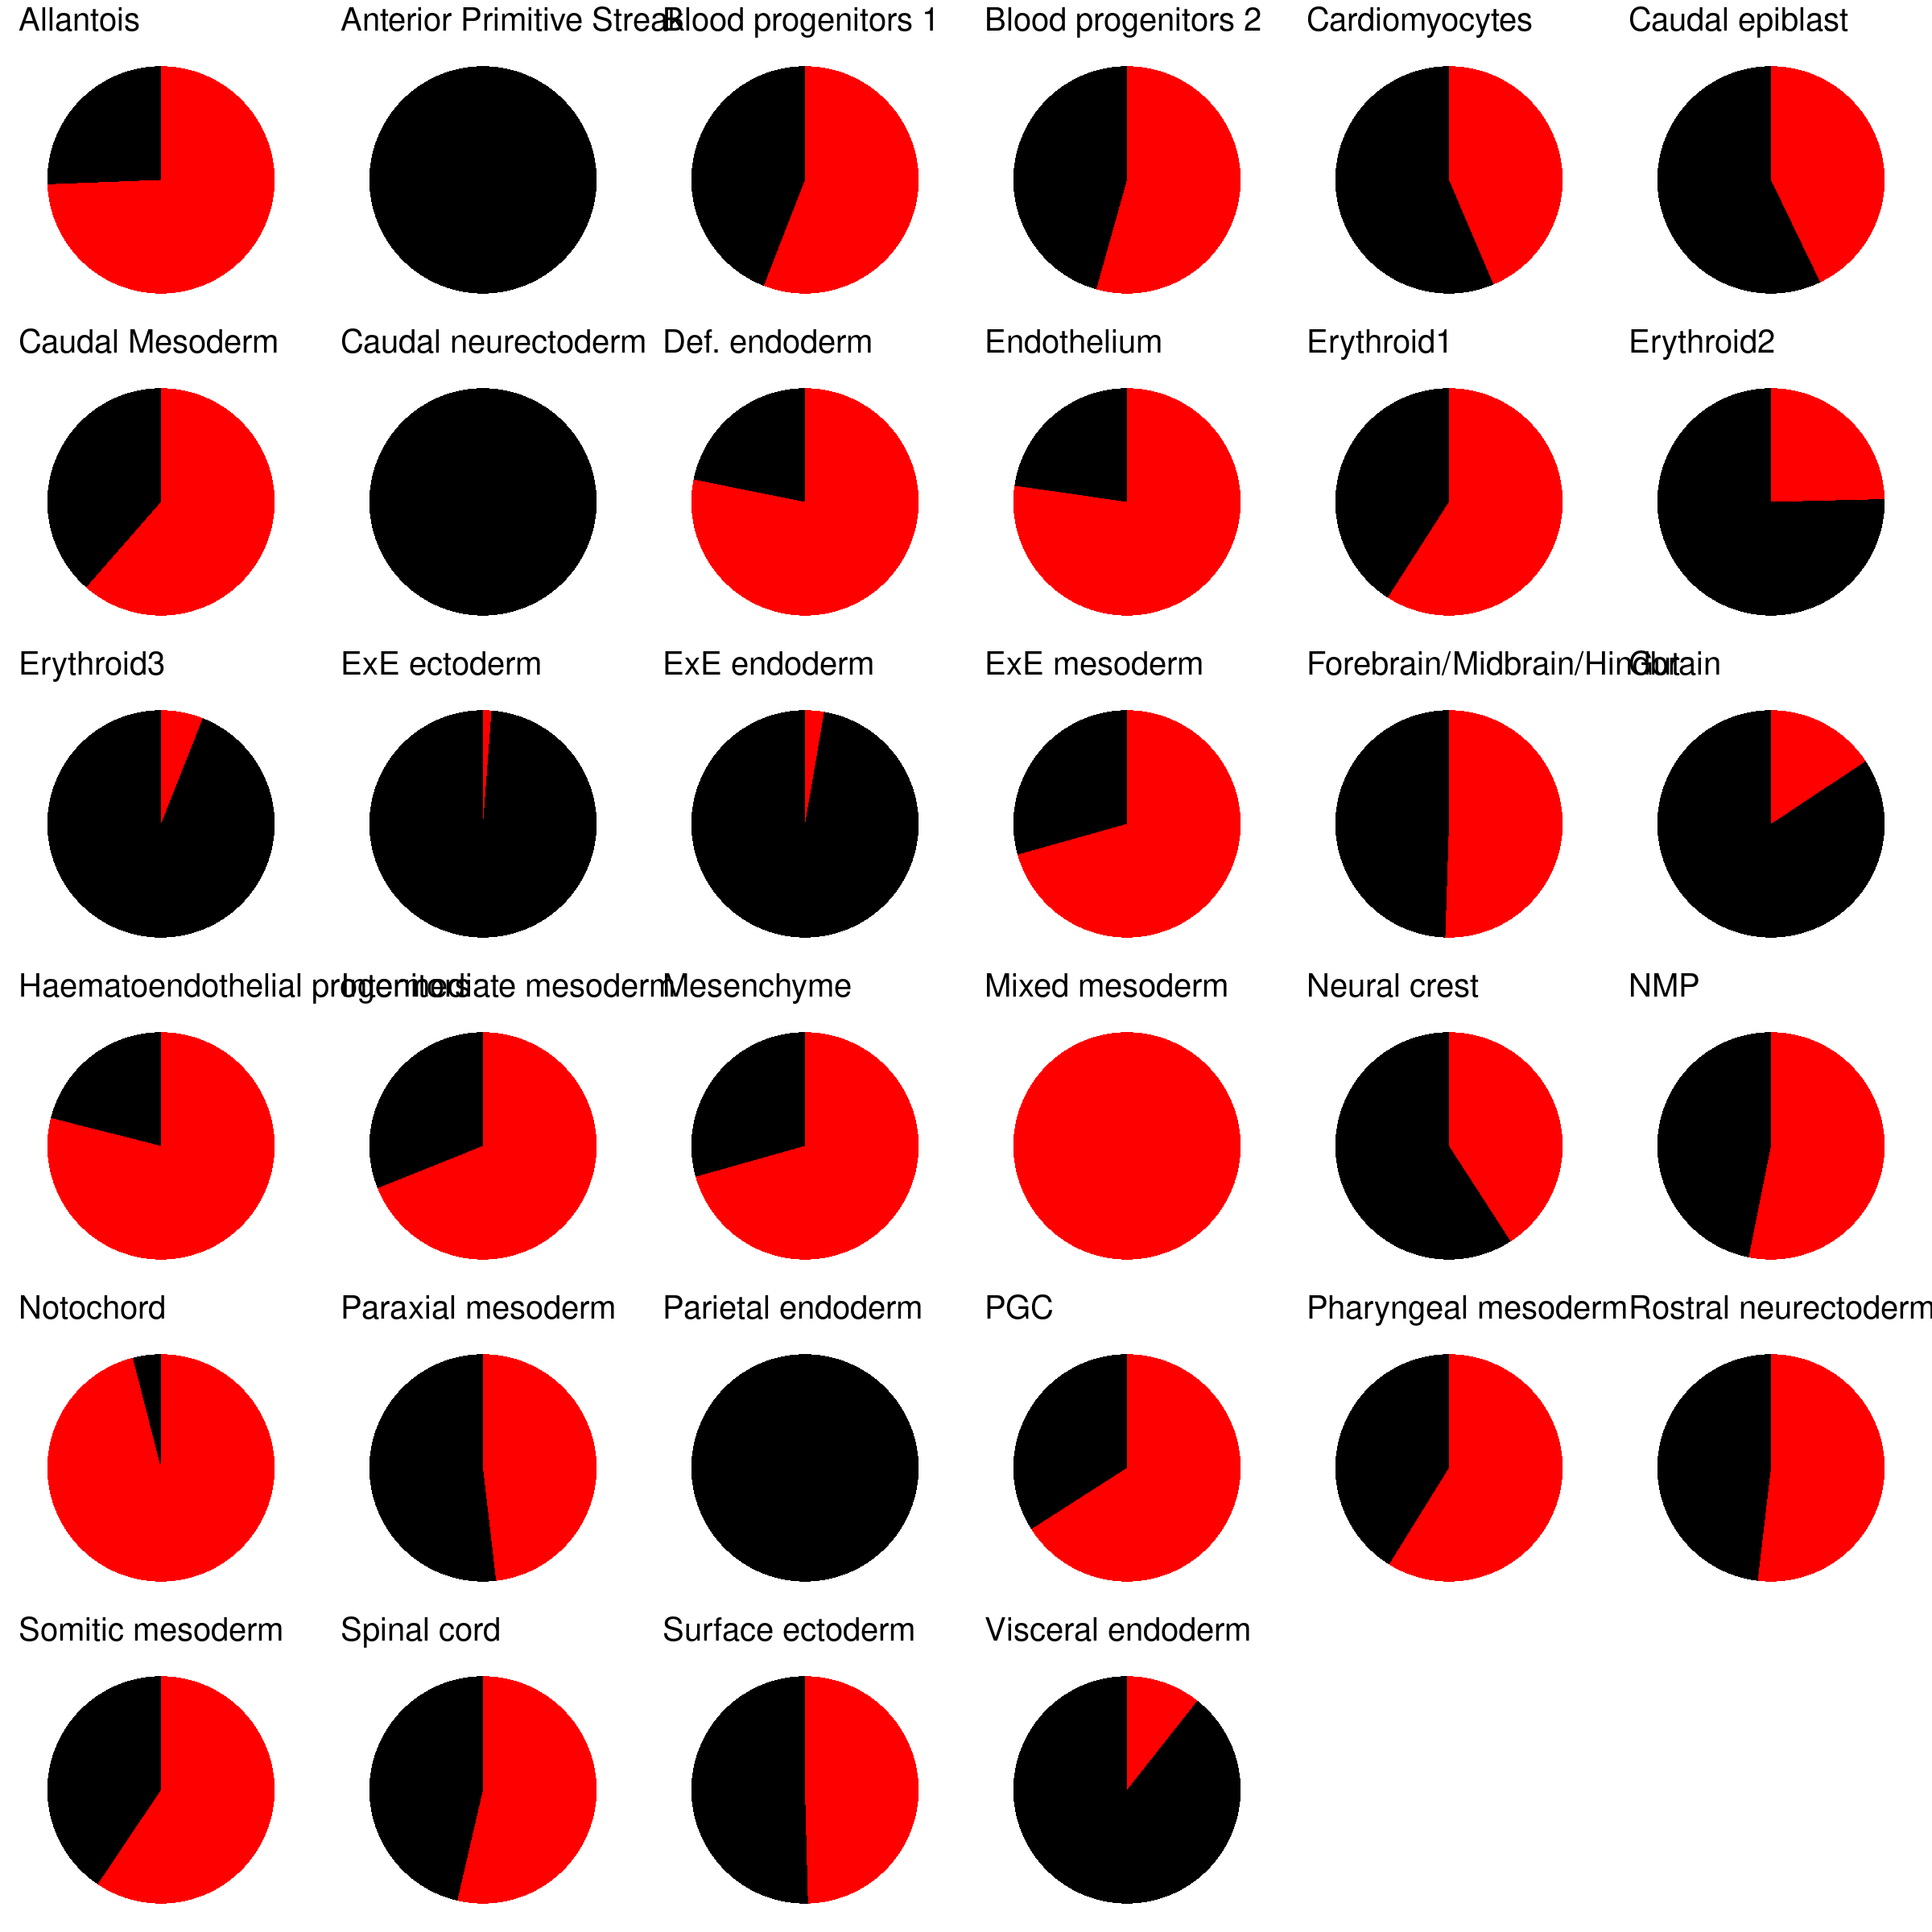

In [85]:
options(repr.plot.width = 20, repr.plot.height = 20)
CombinePlots(plots, ncol = 6)